In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [4]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [5]:
X.shape

(1338, 6)

In [6]:
type(X)

pandas.core.frame.DataFrame

In [7]:
X = pd.get_dummies(X,columns = ["sex", "region", "smoker"], drop_first=True)

In [8]:
X.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
0,19,27.900,0,False,False,False,True,True
1,18,33.770,1,True,False,True,False,False
2,28,33.000,3,True,False,True,False,False
3,33,22.705,0,True,True,False,False,False
4,32,28.880,0,True,True,False,False,False


In [9]:
X = X.astype(int)

In [10]:
X.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
0,19,27,0,0,0,0,1,1
1,18,33,1,1,0,1,0,0
2,28,33,3,1,0,1,0,0
3,33,22,0,1,1,0,0,0
4,32,28,0,1,1,0,0,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared: 0.78
Mean Absolute Error (MAE): 4176.26
Mean Squared Error (MSE): 33566618.89
Root Mean Squared Error (RMSE): 5793.67


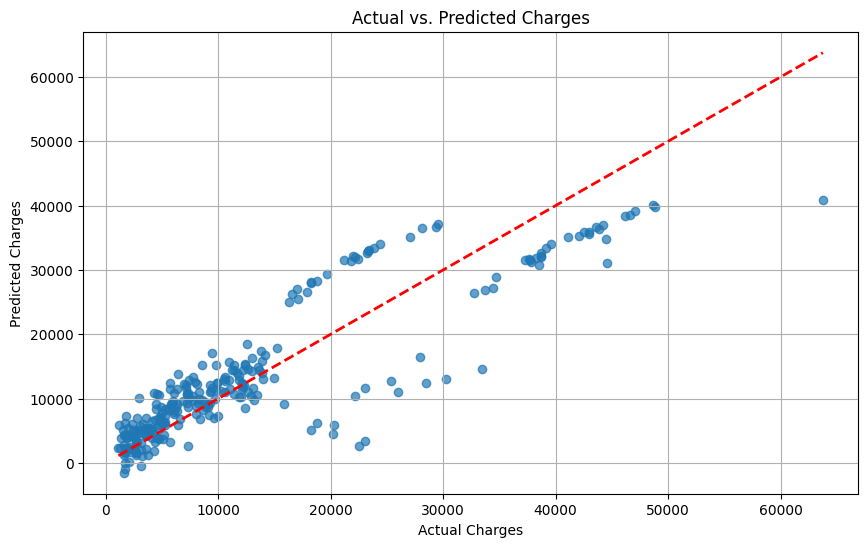

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Charges')
plt.grid(True)

In [15]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_poly_pred = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, y_poly_pred)
poly_mae = mean_absolute_error(y_test, y_poly_pred)
poly_mse = mean_squared_error(y_test, y_poly_pred)
poly_rmse = np.sqrt(poly_mse)

print(f"Polynomial Regression (Degree 2) Metrics:")
print(f"R-squared: {poly_r2:.2f}")
print(f"Mean Absolute Error (MAE): {poly_mae:.2f}")
print(f"Mean Squared Error (MSE): {poly_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {poly_rmse:.2f}")

Polynomial Regression (Degree 2) Metrics:
R-squared: 0.87
Mean Absolute Error (MAE): 2721.91
Mean Squared Error (MSE): 20851654.89
Root Mean Squared Error (RMSE): 4566.36


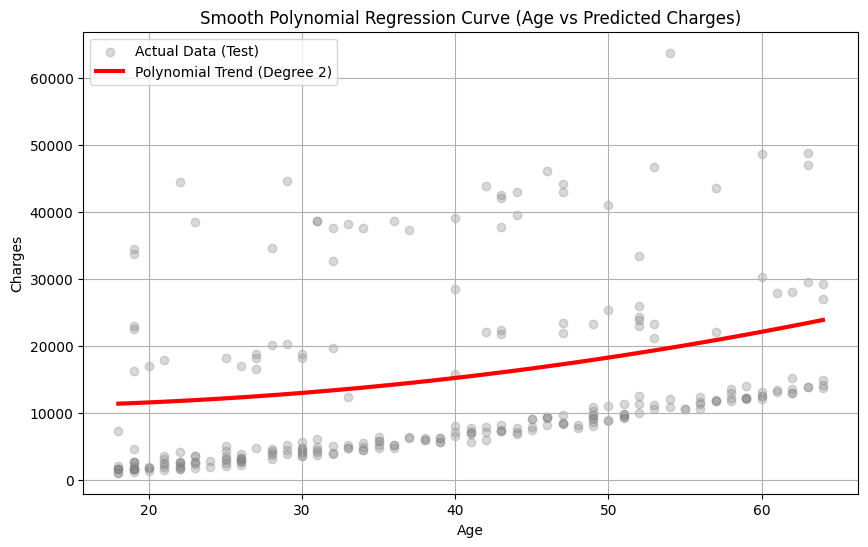

In [16]:
plt.figure(figsize=(10, 6))

age_range = np.linspace(X['age'].min(), X['age'].max(), 100)

X_dummy = pd.DataFrame(np.tile(X_train.mean().values, (100, 1)), columns=X_train.columns)
X_dummy['age'] = age_range

X_dummy_poly = poly.transform(X_dummy)
y_dummy_pred = poly_model.predict(X_dummy_poly)

plt.scatter(X_test['age'], y_test, color='gray', alpha=0.3, label='Actual Data (Test)')
plt.plot(age_range, y_dummy_pred, color='red', lw=3, label=f'Polynomial Trend (Degree {poly.degree})')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Smooth Polynomial Regression Curve (Age vs Predicted Charges)')
plt.legend()
plt.grid(True)
plt.show()